Copyright (C) 2026  Diarmuid

This program is free software: you can redistribute it and/or modify\
it under the terms of the GNU General Public License as published by\
the Free Software Foundation, either version 3 of the License, or\
(at your option) any later version.

This program is distributed in the hope that it will be useful,\
but WITHOUT ANY WARRANTY; without even the implied warranty of\
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the\
GNU General Public License for more details.

You should have received a copy of the GNU General Public License\
along with this program.  If not, see <https://www.gnu.org/licenses/>.

----------------------------------------------------------------------

Author: Diarmuid O'Neill\
Student Number: C00282898\
Date: 02/4/2026\
Brief Description:
This notebook aims to use a Long Short Term Memory Recurrent Neural Network (LSTM RNN) to predict the future power consumption (Global_active_power) of a single house. In a real world scenario, this may be useful for electricty providers who could use consumption forecasting to better anticipate demand and manage grid load. Firstly the Date and Time columns in the dataset need to be combined into a single Datetime column and the sliding window technique must be used to make predictions based on time-series data. The dataset consists of over 2 million datapoints as it is a minute-by-minute recording of power consumption from a house in Sceaux, France over the course of four years (December 2006 - November 2010). \
**IMPORTANT NOTE:** Due to the large size of the dataset, it has not been included in this repository. If you wish to run the code yourself, you must download the dataset from the source below and place it in the root directory (DataScienceProjectPartTwo) and run the code in Jupyter Notebook from there. \
Source: [UCI Machine Learning Repository - Individual Household Electric Power Consumption](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)

In [36]:
# Needed imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random
from tensorflow.keras.callbacks import EarlyStopping
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [24]:
# Importing Dataset
dataset = pd.read_csv("household_power_consumption.txt", sep=";")
dataset.head()

C:\Users\Diarmuid\AppData\Local\Temp\ipykernel_24500\948677931.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("household_power_consumption.txt", sep=";")


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Date and Time are two seperate columns. To use a recurrent neural network a time series is needed. The below code combines the date and time columns into a single Datetime column.

In [25]:
dataset["Datetime"] = pd.to_datetime(dataset["Date"] + " " + dataset["Time"], format="%d/%m/%Y %H:%M:%S")
dataset = dataset.set_index("Datetime")
dataset = dataset.drop(columns=["Date", "Time"])
dataset.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


The target Global_active_power must consist of numeric data. The below code block ensures that this variable consists only of numeric data and drops any N/A values.

In [26]:
dataset["Global_active_power"] = pd.to_numeric(dataset["Global_active_power"], errors="coerce")
dataset = dataset.dropna(subset=["Global_active_power"])
dataset.sort_values("Datetime")
dataset.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Next the daily Global_active_power is plotted to investigate if there are any obvious patterns and to explore the data. There is a noticable pattern in the graph below, energy consumption appears to be higher in Winter months as opposed to Summer months which is expected. 

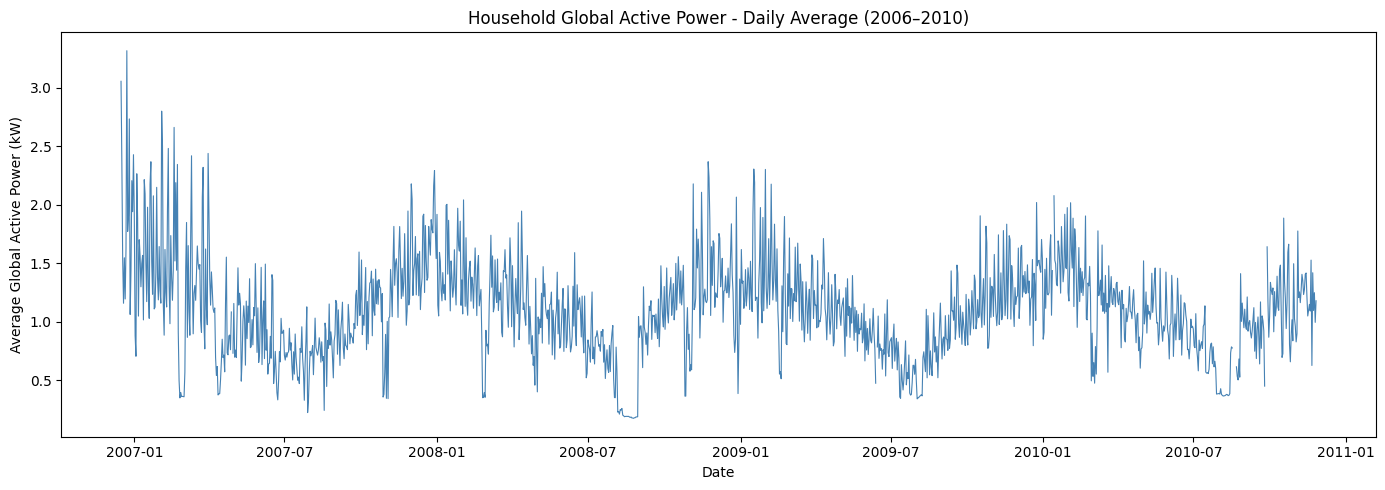

In [27]:
daily = dataset['Global_active_power'].resample('D').mean()

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily.values, color='steelblue', linewidth=0.8)
plt.title("Household Global Active Power - Daily Average (2006–2010)")
plt.xlabel("Date")
plt.ylabel("Average Global Active Power (kW)")
plt.tight_layout()
plt.show()

When splitting the dataset into training and test, it cannot be split randomly. This is because the model cannot use future values of Global_active_power for prediction and past values for evaluation. This is called data leakage. In this case the first 80% of the time series data is used for training and the remaining 20% for testing. This ensures the model is always predicting values it has never seen before. Also the training set is scaled using fit_transform() and the test set is scaled using transform(). This ensures again that there is no data leakage between the test set and training set as taking both sets into account when scaling data will alter all values. Also note training and test are reshaped into 2D arrays as this is what the fit_transform() and transform() functions expect.

In [28]:
split_point = int(len(dataset) * 0.8)

train = dataset["Global_active_power"].values[:split_point]
test  = dataset["Global_active_power"].values[split_point:]

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.reshape(-1, 1))
test_scaled  = scaler.transform(test.reshape(-1, 1))

To make a prediction for each data point the model cannot use the entire dataset, instead a sliding window is used. This technique works by taking a number of previous timesteps (60 in this case) and using this subset to predict the value of the next datapoint. The create_sequences() function below takes in the scaled data and a window size of 60, and returns an array of 60 timesteps for X and a single target value for y. These arrays are then finally reshaped from 2D arrays to 3D arrays (samples, timesteps, features) which is what the model will expect.

In [29]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test,  y_test  = create_sequences(test_scaled)

X_train = X_train.reshape(-1, 60, 1)
X_test  = X_test.reshape(-1, 60, 1)

The below code block defines and compiles the model. A Long Short Term Memory (LSTM) model is used. This is a type of Recurrent Neural Network (RNN) which learns from sequential data while maintaining a memory across timesteps. A typical RNN may struggle to remember patterns it learned from earlier timesteps, this is called the vanishing gradient problem. LSTM models use a combination of Input Gates, Forget Gates and Output Gates to decide what information to remember and what to forget.
### Layer 1
- 64 memory units; this is a standard starting point, large enough to learn patterns but not too large that the model becomes slow or overfits.
- relu activation function; this is standard for regression tasks.
- input_shape(60, 1); defines the shape of the data coming into the model.
- return_sequences=True; this is required for multi-layer models and passes the full 64 outputs to the next layer.
- Dropout(0.2); turns off 20% of neurons to prevent overfitting
### Layer 2
- 32 memory units; reducing the number of memory units at each layer forces the model to compress what it has learned into a smaller representation.
- relu activation function; this is standard for regression tasks.
- return_sequences=False; this is the last LSTM layer in the model and thus just needs to output the single final timestep.
- Dropout(0.2); turns off 20% of neurons to prevent overfitting.
### Dense Layer
- 16 neurons; forces the model to compress what it has learned even more.
### Output Layer
- Dense(1); outputs the predicted Global Active Power value.
### Compile
- optimizer="adam"; adaptive learning rate optimizer.
- loss="mse"; this defines the loss function used for training. Mean Squared Error penalises larger errors more severely than smaller ones.
- metrics="mae"; this defines the metric to track during training. Mean Absolute Error is how far a prediction is off from the actual value and is more interpretible than MSE (Mean Square Error).

In [30]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(60, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

C:\Users\Diarmuid\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In the next code block the model is trained using the training set, over 10 epochs, with a batch size of 256. This means the model pulls in 256 examples from the dataset at a time. This number was chosen to reduce training time as with over two million datapoints, this model takes a very long time to train. Validation_split=0.1 trains the model on the first 90% of data from the training set and then evaluates its performance on the last 10% for each epoch (This is how val_loss and val_mae is calculated). Shuffle also must be set to false due to the chronological nature of the data.

In [31]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 223s 39ms/step - loss: 0.0012 - mae: 0.0174 - val_loss: 0.0010 - val_mae: 0.0183
Epoch 2/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 199s 34ms/step - loss: 7.0837e-04 - mae: 0.0126 - val_loss: 0.0018 - val_mae: 0.0277
Epoch 3/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 196s 34ms/step - loss: 6.5201e-04 - mae: 0.0116 - val_loss: 0.0019 - val_mae: 0.0274
Epoch 4/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 196s 34ms/step - loss: 6.2727e-04 - mae: 0.0112 - val_loss: 0.0020 - val_mae: 0.0291
Epoch 5/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 197s 34ms/step - loss: 6.1832e-04 - mae: 0.0110 - val_loss: 0.0020 - val_mae: 0.0286
Epoch 6/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 193s 34ms/step - loss: 6.0741e-04 - mae: 0.0108 - val_loss: 0.0020 - val_mae: 0.0298
Epoch 7/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 192s 33ms/step - loss: 5.9843e-04 - mae: 0.0107 - val_loss: 0.0022 - val_mae: 0.0310
Epoch 8/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 192s 33ms/step - loss: 5.9036e-04 - mae: 0.0105 - val_loss: 0.0022 - val_

The MAE graph below shows training MAE decreasing while validation MAE increases sharply and continues rising steadily. This indicates the model is overfitting to the training data. The loss plot paints a similar picture as training loss decreases validation loss increases sharply at first and then keeps rising steadily, again a clear sign of overfitting.

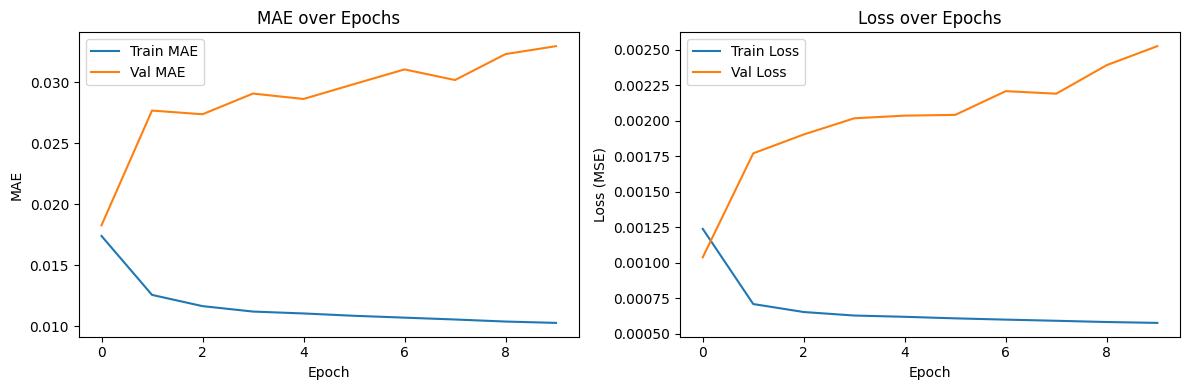

In [33]:
plt.figure(figsize=(12, 4))

# MAE
plt.subplot(1, 2, 1)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("MAE over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()

plt.tight_layout()
plt.show()

The code block below uses the newly trained model to predict Global_active_power minute-by-minute for the test set, given the values for the previous 60 minutes. Note that predictions and y_test_actual use inverse_transform() to to transform them back into kilowatts (kW). This makes the graph more interpretable. The final Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) are also calculated. MAE indicates how far off a prediction is from the actual value and RMSE measures the average size of prediction errors but penalises larger errors more heavily than smaller ones, making it more sensitive to occasional large mispredictions. The graph itself is a subset of 2,000 points from the test set. This is because the whole test set would be over 400,000 points, making the graph unreadable. The blue line in the graph is the actual Global_active_power values and the red line is the predicted values.

12807/12807 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step
Test MAE:  0.2643 kW
Test RMSE: 0.4209 kW


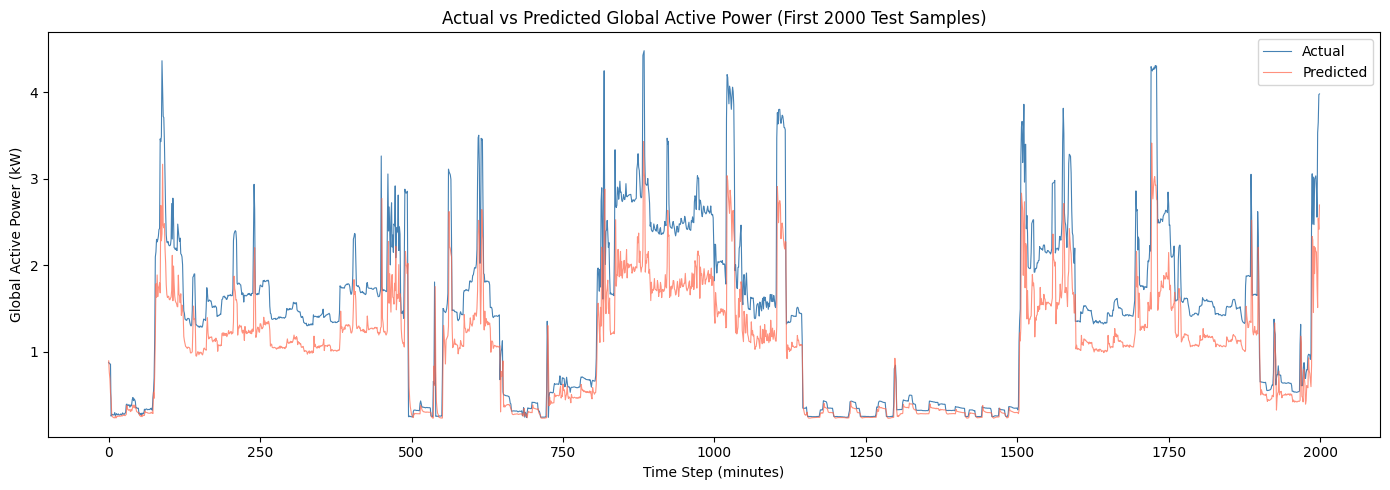

In [35]:
# Make predictions
predictions_scaled = model.predict(X_test)

# Inverse transform back to real kW values
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate error metrics on real values
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Test MAE:  {mae:.4f} kW")
print(f"Test RMSE: {rmse:.4f} kW")

# Plot actual vs predicted - plot a subset of 2000 timesteps so the graph is readable
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:2000], color="steelblue", label="Actual", linewidth=0.8)
plt.plot(predictions[:2000], color="tomato", label="Predicted", linewidth=0.8, alpha=0.7)
plt.title("Actual vs Predicted Global Active Power (First 2000 Test Samples)")
plt.xlabel("Time Step (minutes)")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

The graph above shows that the model can capture the general pattern of consumption but routinely underestimates the peak values. This is likely due to the overfitting which is apparent from the training graphs and Test MAE of 0.2643 kW and Test RMSE of 0.4209 kW. To try and combat overfitting model2 seen below reduces the number of neurons in each layer. This gives the model less capacity to memorise patterns and forces it to find more general patterns. Increasing dropout serves a similar purpose by turning off more neurons randomly, the model is forced to generalise more. The learning rate is also slowed down, this leads to more gradual weight updates and can help the model converge to a solution that generalises better to unseen data.

In [ ]:
# Reducing neurons, gives the model less capacity to memorise
# Increasing dropout, turns off more neurons randomly, forcing model to learn more general patterns
model2 = Sequential([
    LSTM(32, activation='relu', input_shape=(60, 1), return_sequences=True),
    Dropout(0.3),
    LSTM(16, activation='relu', return_sequences=False),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(1)
])

# Slower learning rate can lead to better generalization
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
              loss="mse", metrics=["mae"])
model2.summary()

An EarlyStopping function is also used, which stops training after three epochs where val_loss does not improve.

In [39]:
# early_stop, stops model training when val_loss stops improving
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history2 = model2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stop]
)

Epoch 1/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 101s 17ms/step - loss: 0.0019 - mae: 0.0235 - val_loss: 0.0012 - val_mae: 0.0185
Epoch 2/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 95s 16ms/step - loss: 9.3171e-04 - mae: 0.0156 - val_loss: 0.0015 - val_mae: 0.0220
Epoch 3/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 98s 17ms/step - loss: 7.9801e-04 - mae: 0.0138 - val_loss: 0.0018 - val_mae: 0.0262
Epoch 4/10
5764/5764 ━━━━━━━━━━━━━━━━━━━━ 98s 17ms/step - loss: 7.4379e-04 - mae: 0.0129 - val_loss: 0.0018 - val_mae: 0.0258


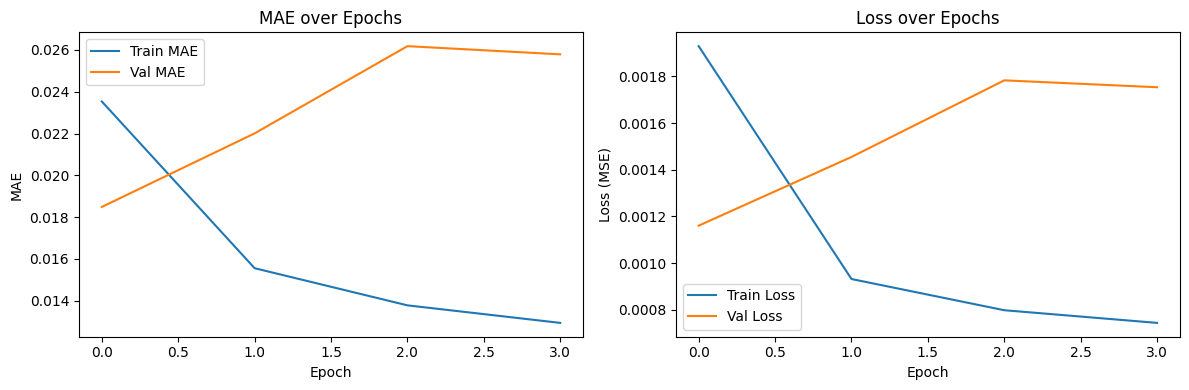

In [40]:
plt.figure(figsize=(12, 4))

# MAE
plt.subplot(1, 2, 1)
plt.plot(history2.history["mae"], label="Train MAE")
plt.plot(history2.history["val_mae"], label="Val MAE")
plt.title("MAE over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history["loss"], label="Train Loss")
plt.plot(history2.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()

plt.tight_layout()
plt.show()

The MAE and Loss graphs above show a similar problem with overfitting though not as severe. This second model also has the added benefit of not taking as long to train as the first model.

12807/12807 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step
Test MAE:  0.1602 kW
Test RMSE: 0.2914 kW


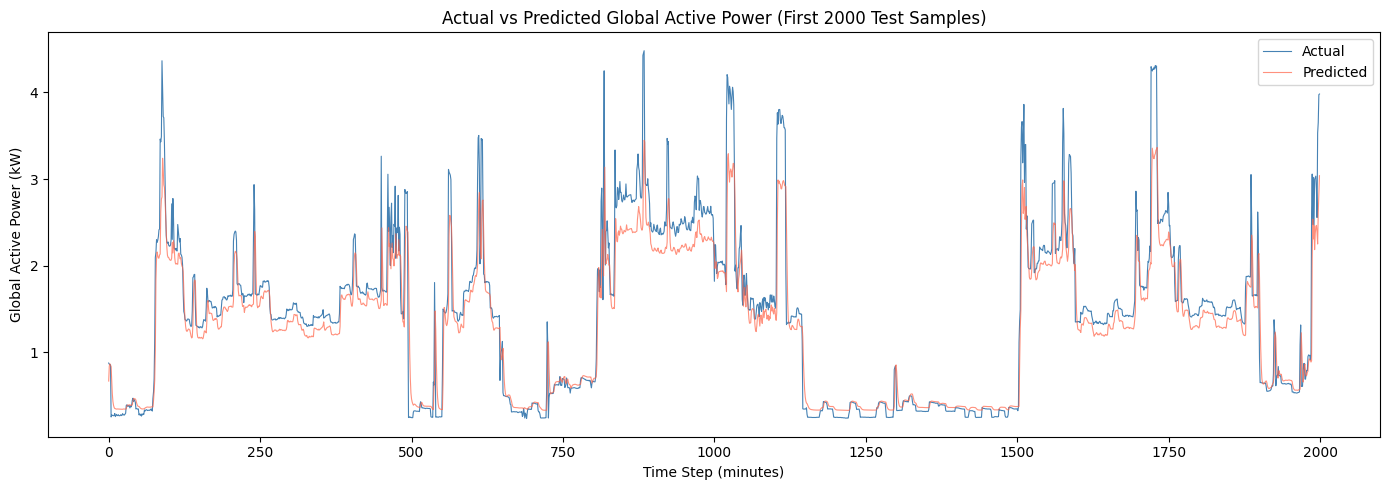

In [41]:
# Make predictions
predictions_scaled = model2.predict(X_test)

# Inverse transform back to real kW values
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate error metrics on real values
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Test MAE:  {mae:.4f} kW")
print(f"Test RMSE: {rmse:.4f} kW")

# Plot actual vs predicted - plot a subset of 2000 timesteps so the graph is readable
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:2000], color="steelblue", label="Actual", linewidth=0.8)
plt.plot(predictions[:2000], color="tomato", label="Predicted", linewidth=0.8, alpha=0.7)
plt.title("Actual vs Predicted Global Active Power (First 2000 Test Samples)")
plt.xlabel("Time Step (minutes)")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

Upon plotting this final graph, though it is not perfect, it appears to be more accurate than the first pass. This time Test MAE is 0.1602 and Test RMSE is 0.2914 an improvement of 0.01041 and 0.1295 respectively.

### Conclusion
To summarise, a Long Short Term Memory Recurrent Neural Network (LSTM RNN) was used to predict the next minute's power consumption (Global_active_power) given the previous 60 minutes using the sliding window technique. To do this the data had to be preprocessed by combining the Date and Time columns into a DateTime column, missing values had to be dropped and the data also had to be scaled. An initial model achieved a Test MAE value of 0.2643 kW and a Test RMSE value of 0.4209 kW however the training graph revealed significant overfitting was occuring. A second, tweaked model was then trained which reduced the number of neurons, increased dropout, used a slower learning rate and used an EarlyStopping callback function. The second model still appears to overfit though it achieved better MAE and RMSE scores at 0.1602 kW and 0.2914 kW respectively.